# Traitment du corpus

Alignement

In [1]:
import xml.etree.ElementTree as ET
import csv

# --- Step 1: Charger le fichier TMX ---
tmx_file = 'fr-zh.tmx'
tree = ET.parse(tmx_file)
root = tree.getroot()

# Namespace TMX, parfois nécessaire
namespace = {'tmx': 'http://www.lisa.org/tmx14'}

# --- Step 2: Extraire les paires alignées ---
pairs = []

for tu in root.iter('tu'):
    fr_text = ""
    zh_text = ""
    for tuv in tu.findall('tuv'):
        lang = tuv.attrib.get('{http://www.w3.org/XML/1998/namespace}lang')
        seg = tuv.find('seg')
        if seg is not None:
            text = seg.text.strip() if seg.text else ""
            if lang == 'fr':
                fr_text = text
            elif lang == 'zh':
                zh_text = text
    if fr_text and zh_text:
        pairs.append((fr_text, zh_text))

# --- Step 3: Sauvegarder les données alignées ---
with open('aligned_fr_zh.tsv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.writer(f, delimiter='\t')
    writer.writerow(['fr', 'zh'])
    writer.writerows(pairs)

print(f"{len(pairs)} paires alignées ont été extraites et sauvegardées dans 'aligned_fr_zh.tsv'")


3063 paires alignées ont été extraites et sauvegardées dans 'aligned_fr_zh.tsv'


Fast-Align

In [2]:
!git clone https://github.com/clab/fast_align.git
!cd fast_align
!mkdir build && cd build
!git clone https://github.com/clab/fast_align.git
!cd fast_align
!mkdir build && cd build
!cmake ..
!make
!cmake ..
!make

Cloning into 'fast_align'...
remote: Enumerating objects: 213, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 213 (delta 32), reused 26 (delta 26), pack-reused 172 (from 1)
Receiving objects: 100% (213/213), 62.05 KiB | 1.15 MiB/s, done.
Resolving deltas: 100% (115/115), done.
fatal: destination path 'fast_align' already exists and is not an empty directory.
mkdir: cannot create directory ‘build’: File exists
CMake Warning:
  Ignoring extra path from command line:

   ".."


CMake Error: The source directory "/" does not appear to contain CMakeLists.txt.
Specify --help for usage, or press the help button on the CMake GUI.
make: *** No targets specified and no makefile found.  Stop.
CMake Warning:
  Ignoring extra path from command line:

   ".."


CMake Error: The source directory "/" does not appear to contain CMakeLists.txt.
Specify --help for usage, or press the help button on the CMake GUI.
make: *** No targets spe

In [3]:
# convert_aligned_tsv_to_fastalign.py
with open('aligned_fr_zh.tsv', 'r', encoding='utf-8') as fin, open('fr_zh_fastalign.txt', 'w', encoding='utf-8') as fout:
    next(fin)  # skip header
    for line in fin:
        fr, zh = line.strip().split('\t')
        fout.write(f"{fr} ||| {zh}\n")


In [ ]:
!./fast_align -i fr_zh_fastalign.txt -d -o -v > aligned.txt

/bin/bash: line 1: ./fast_align: Is a directory


In [4]:
import random

# --- Step 1: Charger les 1000 premières lignes ---
with open("fr_zh_fastalign.txt", "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f if "|||" in line][:1000]

# --- Step 2: Diviser en paires (fr, zh) ---
pairs = [tuple(line.split("|||")) for line in lines]
pairs = [(fr.strip(), zh.strip()) for fr, zh in pairs]

# --- Step 3: Mélanger aléatoirement les paires pour éviter un biais d’ordre ---
random.seed(42)
random.shuffle(pairs)

# --- Step 4: Découpage 800/100/100 ---
train_data = pairs[:800]
dev_data = pairs[800:900]
test_data = pairs[900:]

# --- Step 5: Fonction pour sauvegarder en TSV ---
def save_tsv(data, filename):
    with open(filename, "w", encoding="utf-8") as f:
        f.write("fr\tzh\n")
        for fr, zh in data:
            f.write(f"{fr}\t{zh}\n")

save_tsv(train_data, "train.tsv")
save_tsv(dev_data, "dev.tsv")
save_tsv(test_data, "test.tsv")

print("1000 句对成功分割为 train/dev/test 文件")


1000 句对成功分割为 train/dev/test 文件


# 模型训练Mbart

In [5]:
! pip install transformers datasets sentencepiece


In [6]:
#加载 mBART 模型与 tokenizer


from transformers import MBartTokenizer, MBartForConditionalGeneration

model_name = "facebook/mbart-large-50-many-to-many-mmt"
tokenizer = MBartTokenizer.from_pretrained(model_name)
model = MBartForConditionalGeneration.from_pretrained(model_name)

# 设置语言标签
source_lang = "fr_XX"
target_lang = "zh_CN"
tokenizer.src_lang = source_lang


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'MBart50Tokenizer'. 
The class this function is called from is 'MBartTokenizer'.


model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

In [7]:

# 加载 TSV 格式数据（train.tsv / dev.tsv / test.tsv）

from datasets import Dataset
import pandas as pd

data_files = {
    "train": "train.tsv",
    "validation": "dev.tsv",
    "test": "test.tsv"
}

# Load data using pandas first
train_df = pd.read_csv(data_files["train"], sep="\t")
validation_df = pd.read_csv(data_files["validation"], sep="\t")
test_df = pd.read_csv(data_files["test"], sep="\t")

# Convert pandas DataFrames to Dataset objects
raw_datasets = {
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(validation_df),
    "test": Dataset.from_pandas(test_df)
}

# Wrap in DatasetDict
from datasets import DatasetDict
raw_datasets = DatasetDict(raw_datasets)

# Print to confirm loading
print(raw_datasets)

DatasetDict({
    train: Dataset({
        features: ['fr', 'zh'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['fr', 'zh'],
        num_rows: 100
    })
    test: Dataset({
        features: ['fr', 'zh'],
        num_rows: 100
    })
})


In [9]:
# ===== 1. 安装必要依赖（如果已经装过可以跳过） =====
!pip install transformers datasets sentencepiece --quiet

# ===== 2. 导入库，并加载 mBART 模型与分词器 =====
from datasets import Dataset, DatasetDict
import pandas as pd
from transformers import MBartTokenizer, MBartForConditionalGeneration

# 2.1 模型名称
model_name = "facebook/mbart-large-50-many-to-many-mmt"

# 2.2 初始化 mBART 的 Tokenizer 和 Model
tokenizer = MBartTokenizer.from_pretrained(model_name)
model = MBartForConditionalGeneration.from_pretrained(model_name)

# 2.3 设置源语言和目标语言标签
#     “fr_XX” 是 mBART 里对应法语的 code，“zh_CN” 对应中文。
source_lang = "fr_XX"
target_lang = "zh_CN"

tokenizer.src_lang = source_lang
tokenizer.tgt_lang = target_lang


# ===== 3. 读取本地 TSV 文件，转成 pandas.DataFrame =====
data_files = {
    "train": "train.tsv",
    "validation": "dev.tsv",
    "test": "test.tsv"
}

train_df      = pd.read_csv(data_files["train"], sep="\t")
validation_df = pd.read_csv(data_files["validation"], sep="\t")
test_df       = pd.read_csv(data_files["test"], sep="\t")

# ===== 4. 把 DataFrame 转成 HuggingFace Dataset，并去掉 pandas 默认的 index 列 =====
raw_datasets = DatasetDict({
    "train":      Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(validation_df, preserve_index=False),
    "test":       Dataset.from_pandas(test_df, preserve_index=False)
})

# 打印原始数据集结构，确认“fr”和“zh”两列都存在
print(raw_datasets)
# 期望输出：
# DatasetDict({
#     train: Dataset({
#         features: ['fr', 'zh'],
#         num_rows: 800
#     })
#     validation: Dataset({
#         features: ['fr', 'zh'],
#         num_rows: 100
#     })
#     test: Dataset({
#         features: ['fr', 'zh'],
#         num_rows: 100
#     })
# })


# ===== 5. 定义 preprocess_function —— 专门给 mBART 用 =====
max_length = 128

def preprocess_function(examples):
    """
    这个函数会被 map(batched=True) 调用：
    - examples["fr"]: 是一个 List[Any]，可能包含 NaN、数字、None 等。
    - examples["zh"]: 同理，目标文本列表。
    我们需要保证传给 tokenizer 的一定是 List[str]。
    """
    # 5.1 确认列名 "fr"、"zh" 都在
    if "fr" not in examples or "zh" not in examples:
        raise ValueError(f"Expected columns ['fr','zh'], but got {list(examples.keys())}")

    # 5.2 取出原始的“法语”和“中文”列
    inputs  = examples["fr"]
    targets = examples["zh"]

    # 5.3 如果 inputs/targets 不是 list，就把它们包装成 list
    if not isinstance(inputs, list):
        inputs = [inputs]
    if not isinstance(targets, list):
        targets = [targets]

    # 5.4 把列表里的每个元素都转成 str，避免出现 NaN、None、数字等导致的类型错误
    inputs  = [str(x) if x is not None else "" for x in inputs]
    targets = [str(x) if x is not None else "" for x in targets]

    # 5.5 用 mBART 的 tokenizer 对“法语”做 encode
    #     注意：这里不需要传入 src_lang，因为我们在外面已设置 tokenizer.src_lang = "fr_XX"
    model_inputs = tokenizer(
        inputs,
        max_length=max_length,
        truncation=True,
        padding="max_length",
    )

    # 5.6 用 with tokenizer.as_target_tokenizer() 对“中文”做 encode
    #     这样 mBART 会自动在开头插入对应的 <zh_CN> token 作为 decoder_start_token。
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            targets,
            max_length=max_length,
            truncation=True,
            padding="max_length",
        )

    # 5.7 把 labels 的 input_ids 放到 model_inputs["labels"]
    model_inputs["labels"] = labels["input_ids"]

    # **注意：mBART 的 Trainer 会根据 “labels” 自动生成 decoder_input_ids**
    # 如果非要手动生成，也可以写：
    # model_inputs["decoder_input_ids"] = model.prepare_decoder_input_ids_from_labels(labels["input_ids"])
    # 但不写也没问题，因为 Trainer 会自动处理。

    return model_inputs


# ===== 6. 用 map 对整个 raw_datasets 进行批量处理 =====
tokenized_datasets = raw_datasets.map(
    preprocess_function,
    batched=True,
    remove_columns=raw_datasets["train"].column_names  # 删除原始的 "fr","zh" 列
)

# ===== 7. 打印 tokenized_datasets，确认字段 =====
print(tokenized_datasets)

# DatasetDict({
#     train: Dataset({
#         features: ['input_ids', 'attention_mask', 'labels'],
#         num_rows: 800
#     })
#     validation: Dataset({
#         features: ['input_ids', 'attention_mask', 'labels'],
#         num_rows: 100
#     })
#     test: Dataset({
#         features: ['input_ids', 'attention_mask', 'labels'],
#         num_rows: 100
#     })
# })

# （可选）如果要自己检查一条样本：
# print(tokenized_datasets["train"][0])


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'MBart50Tokenizer'. 
The class this function is called from is 'MBartTokenizer'.


DatasetDict({
    train: Dataset({
        features: ['fr', 'zh'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['fr', 'zh'],
        num_rows: 100
    })
    test: Dataset({
        features: ['fr', 'zh'],
        num_rows: 100
    })
})


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4174: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 100
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 100
    })
})


# 保存token结果

In [10]:
# 假设已经在前面完成了 tokenized_datasets = raw_datasets.map(...)
# 现在只需调用 save_to_disk：

output_dir = "/content/my_tokenized_data"    # 想存在哪个目录都行
tokenized_datasets.save_to_disk(output_dir)
print(f"分词后的数据已保存到：{output_dir}")


Saving the dataset (0/1 shards):   0%|          | 0/800 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

分词后的数据已保存到：/content/my_tokenized_data


In [11]:
!pip install --upgrade transformers


In [12]:
!pip install --upgrade transformers datasets --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 8.7 MB/s eta 0:00:00


In [13]:
#准备训练参数

from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq

training_args = Seq2SeqTrainingArguments(
    output_dir="./mbart_fr_zh_finetuned",
    # Changed evaluation_strategy to eval_strategy
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=5,
    predict_with_generate=True,
    fp16=True,  # 如果使用GPU
    report_to="none",  # 不使用 wandb 或其他平台
)

# Assuming tokenizer and model are defined in previous cells and accessible here
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

# Assuming tokenized_datasets is defined in a previous cell and accessible here
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator
)

/tmp/ipython-input-4293296817.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


# **模型训练大概用了13分钟**






In [14]:
# 启动训练
trainer.train()


Epoch,Training Loss,Validation Loss
1,No log,0.448897
2,No log,0.424442
3,1.388100,0.436431
4,1.388100,0.447103
5,0.123500,0.453112


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200, 'early_stopping': True, 'num_beams': 5}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


TrainOutput(global_step=1000, training_loss=0.7557877769470215, metrics={'train_runtime': 754.9836, 'train_samples_per_second': 5.298, 'train_steps_per_second': 1.325, 'total_flos': 1083564883968000.0, 'train_loss': 0.7557877769470215, 'epoch': 5.0})

In [15]:
#模型保存


trainer.save_model("mbart_fr_zh_finetuned")
tokenizer.save_pretrained("mbart_fr_zh_finetuned")


('mbart_fr_zh_finetuned/tokenizer_config.json',
 'mbart_fr_zh_finetuned/special_tokens_map.json',
 'mbart_fr_zh_finetuned/sentencepiece.bpe.model',
 'mbart_fr_zh_finetuned/added_tokens.json')

In [17]:
import torch  # 一定要先 import torch 才能调用 torch.cuda.is_available()

# 测试翻译（法语 → 中文）

# 示例输入
text = "Ce médicament est utilisé pour traiter la fièvre."
inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)

# 把 inputs 中的 tensor 全部移到 GPU（如果可用）
if torch.cuda.is_available():
    inputs = {k: v.to('cuda') for k, v in inputs.items()}

# 设置强制 decoder 从中文开始
inputs["forced_bos_token_id"] = tokenizer.lang_code_to_id["zh_CN"]

# 把模型也移到 GPU（如果还没移动的话）
if torch.cuda.is_available():
    model.to('cuda')

# 生成翻译
output_tokens = model.generate(**inputs, max_length=128, num_beams=4)
print(tokenizer.decode(output_tokens[0], skip_special_tokens=True))


该药被用于治疗发热。


In [19]:
import torch

# 假设 tokenizer、model 已经在上一步载入并设置好了
# tokenizer.src_lang = "fr_XX"
# tokenizer.tgt_lang = "zh_CN"
# model.to("cuda") 如果有 GPU

fr_path = "/content/fr.txt"
translated_path = "translated.txt"

with open(fr_path, "r", encoding="utf-8") as fin, \
     open(translated_path, "w", encoding="utf-8") as fout:

    for line in fin:
        french_sentence = line.strip()
        if not french_sentence:
            fout.write("\n")  # 保留空行
            continue

        # 对单句做编码
        inputs = tokenizer(
            french_sentence,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        )

        # 如果有 GPU，把输入移到 GPU
        if torch.cuda.is_available():
            inputs = {k: v.to("cuda") for k, v in inputs.items()}

        # 指定强制从中文开始生成
        inputs["forced_bos_token_id"] = tokenizer.lang_code_to_id["zh_CN"]

        # 生成翻译
        output_tokens = model.generate(
            **inputs,
            max_length=128,
            num_beams=4
        )

        # 解码并写到 translated.txt
        chinese_translation = tokenizer.decode(output_tokens[0], skip_special_tokens=True)
        fout.write(chinese_translation + "\n")

print(f"翻译完成，结果已保存到：{translated_path}")


翻译完成，结果已保存到：translated.txt


#Evaluation

# **添加 BLEU, METEOR, TER, BERTScore, CHRF**

In [21]:
import pandas as pd
import re

# STEP 1：读取原始语料库（分号分隔）
df = pd.read_csv("/content/comparaison_traductions.csv", sep=";", index_col=0)

# STEP 2：清洗结构（去空行、字段空格等）
df = df.dropna(how="all")  # 删除完全空行
df.columns = [col.strip() for col in df.columns]  # 列名去首尾空格
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)  # 单元格去空格

# STEP 3：定义并应用 normalize 函数（标点统一 + 小写）
def normalize(text):
    text = str(text)
    text = text.strip().lower()
    text = re.sub(r"[“”]", "\"", text)
    text = re.sub(r"[，]", ",", text)
    text = re.sub(r"[。]", ".", text)
    text = re.sub(r"[？]", "?", text)
    text = re.sub(r"\s+", " ", text)
    return text

df["zh_ref"] = df["zh_ref"].apply(normalize)
df["zh_google"] = df["zh_google"].apply(normalize)
df["zh_chatgpt"] = df["zh_chatgpt"].apply(normalize)

# STEP 4：保存清洗后的 CSV 文件
df.to_csv("cleaned_comparaison.csv", index=False)


/tmp/ipython-input-1595237497.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)  # 单元格去空格


In [22]:
!pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [23]:
!pip install sacrebleu
!pip install nltk  # meteor 依赖它
!pip install git+https://github.com/mjpost/python-ter


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 2.0 MB/s eta 0:00:00
  Cloning https://github.com/mjpost/python-ter to /tmp/pip-req-build-k4ul7rkz
  Running command git clone --filter=blob:none --quiet https://github.com/mjpost/python-ter /tmp/pip-req-build-k4ul7rkz
  fatal: could not read Username for 'https://github.com': No such device or address
  error: subprocess-exited-with-error
  
  × git clone --filter=blob:none --quiet https://github.com/mjpost/python-ter /tmp/pip-req-build-k4ul7rkz did not run successfully.
  │ exit code: 128
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× git clone --filter=blob:none --quiet https://github.com/mjpost/python-ter /tmp/pip-req-build-k4ul7rkz did not run successfully.
│ exit code: 128
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [24]:
!pip install --upgrade datasets transformers --quiet


In [25]:
#导入库并读取 CSV


import pandas as pd
from evaluate import load  # Changed from load_metric
import torch

# 请确保 translations.csv 已经上传到当前工作目录
csv_path = "/content/cleaned_comparaison.csv"
df = pd.read_csv(csv_path, sep=",")
print("CSV 前几行预览：")
print(df.head())


CSV 前几行预览：
                                         fr (source)  \
0      depuis combien ressentez-vous ces symptômes ?   
1  et toutes les douleurs thoraciques doivent êtr...   
2               et surtout si vous avez de la fièvre   
3  et votre cholestérol et votre tension doivent ...   
4           et avez-vous de la fièvre actuellement ?   

                       zh_ref               zh_google  \
0                这些症状已持续多长时间?             您出现这些症状多久了?   
1  各种胸痛均应采取这种方法进行治疗,尤其要考虑年龄因素  所有的胸痛都应该这样治疗,尤其是在你这个年纪   
2                     并伴有发热症状              尤其是当你发烧的时候   
3               还需要检查一下胆固醇和血压         你的胆固醇和血压也应该得到控制   
4                    您现在有发热吗?                 您现在发烧吗?   

                 zh_chatgpt                   zh_mBart  
0          您从什么时候开始感到这些症状的?               这些症状已持续多长时间?  
1  所有胸痛都应按这种方式处理,尤其是在您这个年龄.  所有胸痛均应以这种方式进行治疗,尤其要考虑年龄因素  
2                尤其是如果您发烧了.               尤其是,如果发热症状出现  
3          您的胆固醇和血压也需要进行检查.                您还得控制胆固醇和血压  
4                  您现在有发

In [26]:
# ===== 安装并导入依赖 =====
!pip install --quiet evaluate datasets transformers sacrebleu nltk git+https://github.com/mjpost/python-ter


  error: subprocess-exited-with-error
  
  × git clone --filter=blob:none --quiet https://github.com/mjpost/python-ter /tmp/pip-req-build-9lwlzv3p did not run successfully.
  │ exit code: 128
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× git clone --filter=blob:none --quiet https://github.com/mjpost/python-ter /tmp/pip-req-build-9lwlzv3p did not run successfully.
│ exit code: 128
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [27]:
!pip install --quiet bert-score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.8 MB/s eta 0:00:00


In [28]:
import pandas as pd
import torch
from evaluate import load  # 用 load(...) 来加载评价指标


In [29]:
# ===== 1. 读取 CSV 并查看列名 =====
csv_path = "/content/cleaned_comparaison.csv"  # 根据实际路径修改
df = pd.read_csv(csv_path, sep=",")            # 如果分隔符是制表符，请改为 sep="\t"

print("=== CSV 的列名（columns） ===")
print(df.columns.tolist())

=== CSV 的列名（columns） ===
['fr (source)', 'zh_ref', 'zh_google', 'zh_chatgpt', 'zh_mBart']


In [30]:
# ===== 2. Extract required text lists according to actual column names =====
# The following lines: column names must exactly match those printed above (including spaces and parentheses)
sources             = df["fr (source)"].astype(str).tolist()    # French source sentences
references          = df["zh_ref"].astype(str).tolist()         # Reference Chinese
predictions_google  = df["zh_google"].astype(str).tolist()      # Google translations
predictions_chatgpt = df["zh_chatgpt"].astype(str).tolist()     # ChatGPT translations
predictions_mbart   = df["zh_mBart"].astype(str).tolist()       #  mBART model's translations

# ===== 3. Load evaluation metrics =====
bleu      = load("bleu")
meteor    = load("meteor")
ter       = load("ter")
bertscore = load("bertscore")
chrf      = load("chrf")

# ===== 4. Construct reference format required by BLEU/METEOR/TER (List[List[str]]) =====
references_for_metrics = [[ref] for ref in references]

# ===== 5. Compute and print metrics for Reference vs Google translations =====
print("\n=== Metrics for Reference vs Google translations ===")
bleu_google = bleu.compute(predictions=predictions_google, references=references_for_metrics)
print(f"BLEU: {bleu_google['bleu']:.4f}")
print(f"  n-gram precisions: {bleu_google['precisions']}")
print(f"  Brevity Penalty: {bleu_google['brevity_penalty']:.4f}, reference length: {bleu_google['reference_length']}, translation length: {bleu_google['translation_length']}")

meteor_google = meteor.compute(predictions=predictions_google, references=references_for_metrics)
print(f"METEOR: {meteor_google['meteor']:.4f}")

ter_google = ter.compute(predictions=predictions_google, references=references_for_metrics)
print(f"TER: {ter_google['score']:.4f}")

bert_google = bertscore.compute(predictions=predictions_google, references=references, lang="zh")
avg_p_g = sum(bert_google["precision"]) / len(bert_google["precision"])
avg_r_g = sum(bert_google["recall"])    / len(bert_google["recall"])
avg_f1_g = sum(bert_google["f1"])       / len(bert_google["f1"])
print(f"BERTScore → Precision: {avg_p_g:.4f}, Recall: {avg_r_g:.4f}, F1: {avg_f1_g:.4f}")

chrf_google = chrf.compute(predictions=predictions_google, references=references)
print(f"CHRF: {chrf_google['score']:.4f}")

# ===== 6. Compute and print metrics for Reference vs ChatGPT translations =====
print("\n=== Metrics for Reference vs ChatGPT translations ===")
bleu_chatgpt = bleu.compute(predictions=predictions_chatgpt, references=references_for_metrics)
print(f"BLEU: {bleu_chatgpt['bleu']:.4f}")
print(f"  n-gram precisions: {bleu_chatgpt['precisions']}")
print(f"  Brevity Penalty: {bleu_chatgpt['brevity_penalty']:.4f}, reference length: {bleu_chatgpt['reference_length']}, translation length: {bleu_chatgpt['translation_length']}")

meteor_chatgpt = meteor.compute(predictions=predictions_chatgpt, references=references_for_metrics)
print(f"METEOR: {meteor_chatgpt['meteor']:.4f}")

ter_chatgpt = ter.compute(predictions=predictions_chatgpt, references=references_for_metrics)
print(f"TER: {ter_chatgpt['score']:.4f}")

bert_chatgpt = bertscore.compute(predictions=predictions_chatgpt, references=references, lang="zh")
avg_p_c = sum(bert_chatgpt["precision"]) / len(bert_chatgpt["precision"])
avg_r_c = sum(bert_chatgpt["recall"])    / len(bert_chatgpt["recall"])
avg_f1_c = sum(bert_chatgpt["f1"])       / len(bert_chatgpt["f1"])
print(f"BERTScore → Precision: {avg_p_c:.4f}, Recall: {avg_r_c:.4f}, F1: {avg_f1_c:.4f}")

chrf_chatgpt = chrf.compute(predictions=predictions_chatgpt, references=references)
print(f"CHRF: {chrf_chatgpt['score']:.4f}")

# ===== 7. Compute and print metrics for Reference vs mBART model translations =====
print("\n=== Metrics for Reference vs mBART model translations ===")
bleu_mbart = bleu.compute(predictions=predictions_mbart, references=references_for_metrics)
print(f"BLEU: {bleu_mbart['bleu']:.4f}")
print(f"  n-gram precisions: {bleu_mbart['precisions']}")
print(f"  Brevity Penalty: {bleu_mbart['brevity_penalty']:.4f}, reference length: {bleu_mbart['reference_length']}, translation length: {bleu_mbart['translation_length']}")

meteor_mbart = meteor.compute(predictions=predictions_mbart, references=references_for_metrics)
print(f"METEOR: {meteor_mbart['meteor']:.4f}")

ter_mbart = ter.compute(predictions=predictions_mbart, references=references_for_metrics)
print(f"TER: {ter_mbart['score']:.4f}")

bert_mbart = bertscore.compute(predictions=predictions_mbart, references=references, lang="zh")
avg_p_m = sum(bert_mbart["precision"]) / len(bert_mbart["precision"])
avg_r_m = sum(bert_mbart["recall"])    / len(bert_mbart["recall"])
avg_f1_m = sum(bert_mbart["f1"])       / len(bert_mbart["f1"])
print(f"BERTScore → Precision: {avg_p_m:.4f}, Recall: {avg_r_m:.4f}, F1: {avg_f1_m:.4f}")

chrf_mbart = chrf.compute(predictions=predictions_mbart, references=references)
print(f"CHRF: {chrf_mbart['score']:.4f}")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



=== Metrics for Reference vs Google translations ===
BLEU: 0.0000
  n-gram precisions: [0.23163841807909605, 0.0, 0.0, 0.0]
  Brevity Penalty: 1.0000, reference length: 165, translation length: 177
METEOR: 0.0856
TER: 97.2222


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/269k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/412M [00:00<?, ?B/s]

BERTScore → Precision: 0.8213, Recall: 0.8268, F1: 0.8233
CHRF: 29.0149

=== Metrics for Reference vs ChatGPT translations ===
BLEU: 0.0000
  n-gram precisions: [0.19491525423728814, 0.03676470588235294, 0.02631578947368421, 0.0]
  Brevity Penalty: 1.0000, reference length: 165, translation length: 236
METEOR: 0.0950
TER: 96.2963
BERTScore → Precision: 0.7980, Recall: 0.8305, F1: 0.8132
CHRF: 29.0651

=== Metrics for Reference vs mBART model translations ===
BLEU: 0.0000
  n-gram precisions: [0.2893401015228426, 0.061855670103092786, 0.0, 0.0]
  Brevity Penalty: 1.0000, reference length: 165, translation length: 197
METEOR: 0.1766
TER: 85.1852
BERTScore → Precision: 0.8611, Recall: 0.8572, F1: 0.8582
CHRF: 39.5699


In [31]:
# ===== 2. 根据实际列名提取所需文本列表 =====
sources             = df["fr (source)"].astype(str).tolist()    # 法语源句
references          = df["zh_ref"].astype(str).tolist()         # 参考中文
predictions_google  = df["zh_google"].astype(str).tolist()      # Google 翻译
predictions_chatgpt = df["zh_chatgpt"].astype(str).tolist()     # ChatGPT 翻译
predictions_mbart   = df["zh_mBart"].astype(str).tolist()       #  mBART 模型的翻译

# ===== 3. 加载评价指标 =====
bleu      = load("bleu")
meteor    = load("meteor")
ter       = load("ter")
bertscore = load("bertscore")
chrf      = load("chrf")

# ===== 4. 构造 BLEU/METEOR/TER 所需要的参考格式（List[List[str]]） =====
references_for_metrics = [[ref] for ref in references]

# ===== 5. 计算并打印 参考 vs Google 翻译 的指标 =====
print("\n=== 参考 vs Google 翻译 的指标 ===")
bleu_google = bleu.compute(predictions=predictions_google, references=references_for_metrics)
# BLEU 的总分在 'bleu' 键里
print(f"BLEU: {bleu_google['bleu']:.4f}")
print(f"  n-gram 精度: {bleu_google['precisions']}")
print(f"  Brevity Penalty: {bleu_google['brevity_penalty']:.4f}, "
      f"参考长度: {bleu_google['reference_length']}, 翻译长度: {bleu_google['translation_length']}")

meteor_google = meteor.compute(predictions=predictions_google, references=references_for_metrics)
# METEOR 的总分在 'meteor' 键里
print(f"METEOR: {meteor_google['meteor']:.4f}")

ter_google = ter.compute(predictions=predictions_google, references=references_for_metrics)
# TER 的总分在 'score' 键里
print(f"TER: {ter_google['score']:.4f}")

bert_google = bertscore.compute(predictions=predictions_google, references=references, lang="zh")
avg_p_g = sum(bert_google["precision"]) / len(bert_google["precision"])
avg_r_g = sum(bert_google["recall"])    / len(bert_google["recall"])
avg_f1_g= sum(bert_google["f1"])        / len(bert_google["f1"])
print(f"BERTScore → Precision: {avg_p_g:.4f}, Recall: {avg_r_g:.4f}, F1: {avg_f1_g:.4f}")

chrf_google = chrf.compute(predictions=predictions_google, references=references)
# CHRF 的总分在 'score' 键里
print(f"CHRF: {chrf_google['score']:.4f}")

# ===== 6. 计算并打印 参考 vs ChatGPT 翻译 的指标 =====
print("\n=== 参考 vs ChatGPT 翻译 的指标 ===")
bleu_chatgpt = bleu.compute(predictions=predictions_chatgpt, references=references_for_metrics)
print(f"BLEU: {bleu_chatgpt['bleu']:.4f}")
print(f"  n-gram 精度: {bleu_chatgpt['precisions']}")
print(f"  Brevity Penalty: {bleu_chatgpt['brevity_penalty']:.4f}, "
      f"参考长度: {bleu_chatgpt['reference_length']}, 翻译长度: {bleu_chatgpt['translation_length']}")

meteor_chatgpt = meteor.compute(predictions=predictions_chatgpt, references=references_for_metrics)
print(f"METEOR: {meteor_chatgpt['meteor']:.4f}")

ter_chatgpt = ter.compute(predictions=predictions_chatgpt, references=references_for_metrics)
print(f"TER: {ter_chatgpt['score']:.4f}")

bert_chatgpt = bertscore.compute(predictions=predictions_chatgpt, references=references, lang="zh")
avg_p_c = sum(bert_chatgpt["precision"]) / len(bert_chatgpt["precision"])
avg_r_c = sum(bert_chatgpt["recall"])    / len(bert_chatgpt["recall"])
avg_f1_c= sum(bert_chatgpt["f1"])        / len(bert_chatgpt["f1"])
print(f"BERTScore → Precision: {avg_p_c:.4f}, Recall: {avg_r_c:.4f}, F1: {avg_f1_c:.4f}")

chrf_chatgpt = chrf.compute(predictions=predictions_chatgpt, references=references)
print(f"CHRF: {chrf_chatgpt['score']:.4f}")

# ===== 7. 计算并打印 参考 vs  mBART 模型 翻译 的指标 =====
print("\n=== 参考 vs  mBART 模型 翻译 的指标 ===")
bleu_mbart = bleu.compute(predictions=predictions_mbart, references=references_for_metrics)
print(f"BLEU: {bleu_mbart['bleu']:.4f}")
print(f"  n-gram 精度: {bleu_mbart['precisions']}")
print(f"  Brevity Penalty: {bleu_mbart['brevity_penalty']:.4f}, "
      f"参考长度: {bleu_mbart['reference_length']}, 翻译长度: {bleu_mbart['translation_length']}")

meteor_mbart = meteor.compute(predictions=predictions_mbart, references=references_for_metrics)
print(f"METEOR: {meteor_mbart['meteor']:.4f}")

ter_mbart = ter.compute(predictions=predictions_mbart, references=references_for_metrics)
print(f"TER: {ter_mbart['score']:.4f}")

bert_mbart = bertscore.compute(predictions=predictions_mbart, references=references, lang="zh")
avg_p_m = sum(bert_mbart["precision"]) / len(bert_mbart["precision"])
avg_r_m = sum(bert_mbart["recall"])    / len(bert_mbart["recall"])
avg_f1_m= sum(bert_mbart["f1"])        / len(bert_mbart["f1"])
print(f"BERTScore → Precision: {avg_p_m:.4f}, Recall: {avg_r_m:.4f}, F1: {avg_f1_m:.4f}")

chrf_mbart = chrf.compute(predictions=predictions_mbart, references=references)
print(f"CHRF: {chrf_mbart['score']:.4f}")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



=== 参考 vs Google 翻译 的指标 ===
BLEU: 0.0000
  n-gram 精度: [0.23163841807909605, 0.0, 0.0, 0.0]
  Brevity Penalty: 1.0000, 参考长度: 165, 翻译长度: 177
METEOR: 0.0856
TER: 97.2222
BERTScore → Precision: 0.8213, Recall: 0.8268, F1: 0.8233
CHRF: 29.0149

=== 参考 vs ChatGPT 翻译 的指标 ===
BLEU: 0.0000
  n-gram 精度: [0.19491525423728814, 0.03676470588235294, 0.02631578947368421, 0.0]
  Brevity Penalty: 1.0000, 参考长度: 165, 翻译长度: 236
METEOR: 0.0950
TER: 96.2963
BERTScore → Precision: 0.7980, Recall: 0.8305, F1: 0.8132
CHRF: 29.0651

=== 参考 vs  mBART 模型 翻译 的指标 ===
BLEU: 0.0000
  n-gram 精度: [0.2893401015228426, 0.061855670103092786, 0.0, 0.0]
  Brevity Penalty: 1.0000, 参考长度: 165, 翻译长度: 197
METEOR: 0.1766
TER: 85.1852
BERTScore → Precision: 0.8611, Recall: 0.8572, F1: 0.8582
CHRF: 39.5699


#没有preentrainé 的Mbart翻译

#avec le modèle mBART pré-entraîné, sans fine-tuning :

In [32]:
import torch
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast

# 1. Load the pretrained mBART-50 model & tokenizer
model_name = "facebook/mbart-large-50-many-to-many-mmt"
tokenizer = MBart50TokenizerFast.from_pretrained(model_name)
model = MBartForConditionalGeneration.from_pretrained(model_name)

# If you have a GPU, move the model to the GPU
if torch.cuda.is_available():
    model.to('cuda')
    print("Model moved to GPU.")

# 2. Specify source & target languages
tokenizer.src_lang = "fr_XX"
tokenizer.tgt_lang = "zh_CN"
target_id = tokenizer.lang_code_to_id["zh_CN"] # ensure it exists

fr_path = "fr.txt"
translated_path = "translationNotuning.txt" # Match the desired output filename

# 3. Read source file line by line and translate each sentence
with open(fr_path, "r", encoding="utf-8") as fin, \
     open(translated_path, "w", encoding="utf-8") as fout:

    for line in fin:
        french_sentence = line.strip()

        # Handle empty lines by writing a newline character
        if not french_sentence:
            fout.write("\n")
            continue

        # 4. Tokenize the single sentence
        # Add truncation and max_length to handle potentially long individual sentences
        inputs = tokenizer(
            french_sentence,
            return_tensors="pt",
            padding=True, # Pad this single sentence if needed (less likely with one sentence)
            truncation=True, # Truncate if the single sentence is too long
            max_length=1024 # Set a max length appropriate for the model and memory
        )

        # 5. Move inputs to GPU if available
        if torch.cuda.is_available():
            inputs = {k: v.to("cuda") for k, v in inputs.items()}

        # 6. Specify forced decoder start token for the target language
        inputs["forced_bos_token_id"] = target_id

        # 7. Generate translation for the single sentence
        # Adjust max_length here as well, ensuring it doesn't exceed positional embedding capacity
        output_tokens = model.generate(
            **inputs,
            max_length=1024, # Ensure this doesn't exceed model's max positional embedding size
            num_beams=5,
        )

        # 8. Decode the translation
        chinese_translation = tokenizer.decode(output_tokens[0], skip_special_tokens=True)

        # 9. Write the translated sentence to the output file, followed by a newline
        fout.write(chinese_translation + "\n")

print(f" Translation saved to {translated_path}")

Model moved to GPU.
 Translation saved to translationNotuning.txt


#一次评测全部系统。pretrained, trained, chatgot, google translation

In [34]:
import pandas as pd
from evaluate import load

# ===== 1. 读取 CSV =====
df = pd.read_csv("/content/comparaison_traductions2.csv", sep=";")

sources    = df["fr (source)"].astype(str).tolist()
references = df["zh_ref"].astype(str).tolist()

systems = {
    "Google": df["zh_google"].astype(str).tolist(),
    "ChatGPT": df["zh_chatgpt"].astype(str).tolist(),
    "mBART_finetuned": df["zh_mBart"].astype(str).tolist(),
    "mBART_pretrained": df["zh_mBart_pre"].astype(str).tolist(),
}

references_for_metrics = [[ref] for ref in references]

# ===== 2. 加载指标 =====
bleu = load("bleu")
meteor = load("meteor")
ter = load("ter")
bertscore = load("bertscore")
chrf = load("chrf")

# ===== 3. 统一评测函数 =====
def evaluate_system(name, predictions):
    print(f"\n==============================")
    print(f"System: {name}")
    print(f"==============================")

    bleu_score = bleu.compute(predictions=predictions, references=references_for_metrics)
    meteor_score = meteor.compute(predictions=predictions, references=references_for_metrics)
    ter_score = ter.compute(predictions=predictions, references=references_for_metrics)

    bert = bertscore.compute(predictions=predictions, references=references, lang="zh")
    avg_p = sum(bert["precision"]) / len(bert["precision"])
    avg_r = sum(bert["recall"]) / len(bert["recall"])
    avg_f1 = sum(bert["f1"]) / len(bert["f1"])

    chrf_score = chrf.compute(predictions=predictions, references=references)

    print(f"BLEU:    {bleu_score['bleu']:.4f}")
    print(f"METEOR:  {meteor_score['meteor']:.4f}")
    print(f"TER:     {ter_score['score']:.4f}")
    print(f"BERTScore F1: {avg_f1:.4f}")
    print(f"CHRF:    {chrf_score['score']:.4f}")

    return {
        "system": name,
        "BLEU": bleu_score["bleu"],
        "METEOR": meteor_score["meteor"],
        "TER": ter_score["score"],
        "BERTScore_F1": avg_f1,
        "CHRF": chrf_score["score"]
    }

# ===== 4. 运行全部系统评测 =====
results = []

for system_name, preds in systems.items():
    res = evaluate_system(system_name, preds)
    results.append(res)

# ===== 5. 生成结果表格 =====
results_df = pd.DataFrame(results)
print("\n\n===== Summary Table =====")
print(results_df)

results_df.to_csv("evaluation_results_summary.csv", index=False)
print("\n✔ Results saved to evaluation_results_summary.csv")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



System: Google
BLEU:    0.0000
METEOR:  0.0160
TER:     97.1698
BERTScore F1: 0.8203
CHRF:    27.8565

System: ChatGPT
BLEU:    0.0000
METEOR:  0.0070
TER:     99.0566
BERTScore F1: 0.8095
CHRF:    27.1304

System: mBART_finetuned
BLEU:    0.0000
METEOR:  0.0765
TER:     90.5660
BERTScore F1: 0.8542
CHRF:    37.7573

System: mBART_pretrained
BLEU:    0.0000
METEOR:  0.0015
TER:     578.3019
BERTScore F1: 0.5113
CHRF:    1.2547


===== Summary Table =====
             system  BLEU    METEOR         TER  BERTScore_F1       CHRF
0            Google   0.0  0.016042   97.169811      0.820315  27.856511
1           ChatGPT   0.0  0.007000   99.056604      0.809483  27.130409
2   mBART_finetuned   0.0  0.076469   90.566038      0.854220  37.757271
3  mBART_pretrained   0.0  0.001538  578.301887      0.511306   1.254704

✔ Results saved to evaluation_results_summary.csv


#转化TSV

In [ ]:
import pandas as pd

input_path = "/content/annotation _Mbart.csv"
output_path = "/content/annotation_new_mqm.tsv"

df = pd.read_csv(input_path, sep=";")   # 你的原文件是分号分隔

# 去掉列名空格
df.columns = df.columns.str.strip()

# 按 Marot 推荐顺序排列列（如有缺失可调整）
columns_order = [
    "system", "doc_id", "seg_id", "rater",
    "source", "target", "category", "severity", "Weight"
]

df = df[columns_order]

df.to_csv(output_path, sep="\t", index=False)

print("已生成真正的 MQM TSV 文件：")
print(output_path)


已生成真正的 MQM TSV 文件：
/content/annotation_new_mqm.tsv


#Mbart的图
*texte en italique*

mBART severity counts:
severity
no-error    26
neutral     33
minor       13
major       13
critical    13
Name: count, dtype: int64


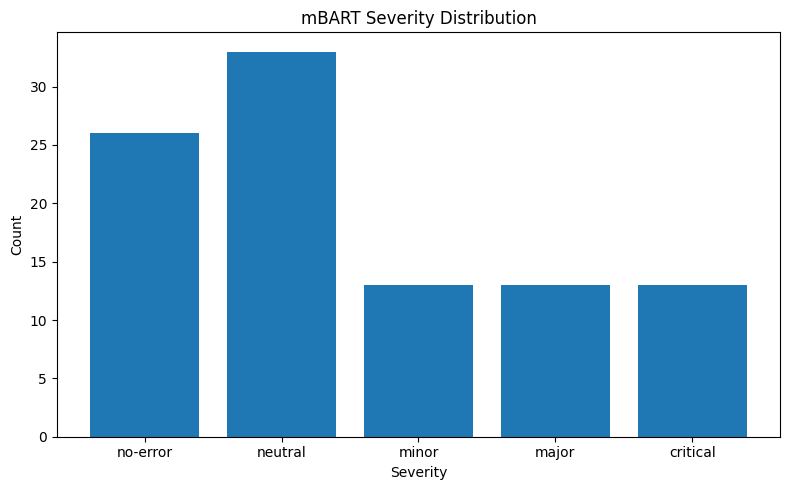

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/content/annotation _Mbart.csv"

# 自动识别分隔符
df = pd.read_csv(file_path, sep=None, engine="python")

df["system"] = df["system"].astype(str).str.strip().str.lower()
df["severity"] = df["severity"].astype(str).str.strip().str.lower()

mbart_df = df[df["system"].isin(["mbart", "m_bart"])]

valid = ["no-error", "neutral", "minor",  "major", "critical"]
mbart_df = mbart_df[mbart_df["severity"].isin(valid)]

counts = mbart_df["severity"].value_counts().reindex(valid, fill_value=0)

print("mBART severity counts:")
print(counts)

plt.figure(figsize=(8,5))
plt.bar(counts.index, counts.values)
plt.title("mBART Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("mbart_severity_distribution.png")
plt.show()


In [ ]:
import csv

input_file = "/content/annotation_Mbart 2.csv"
output_file = "annotation_clean.tsv"

with open(input_file, newline="", encoding="utf-8") as fin, \
     open(output_file, "w", newline="", encoding="utf-8") as fout:

    reader = csv.reader(fin, delimiter=";")
    writer = csv.writer(fout, delimiter="\t", quoting=csv.QUOTE_MINIMAL)

    for row in reader:
        if len(row) < 8:
            continue

        row = row[:8]

        # clean quotes
        row[4] = row[4].replace('"', '').strip()
        row[5] = row[5].replace('"', '').strip()

        # clean severity spaces
        row[7] = row[7].strip()

        writer.writerow(row)

print("Done -> annotation_clean.tsv created")


Done -> annotation_clean.tsv created
